In [22]:
# Запустіть цю комірку один раз, щоб встановити всі необхідні модулі
!pip install numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Імпорт

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, r2_score

KNN-класифікатор

In [24]:
# Дані
df = pd.read_csv('data/fruit_data_with_colors.txt', sep='\t')

# Вибір
X_clf = df[['mass', 'width', 'height', 'color_score']].values
y_clf = df['fruit_label'].values

# Розбиття
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Нормалізація
scaler_clf = StandardScaler()
X_train_clf = scaler_clf.fit_transform(X_train_clf)
X_test_clf = scaler_clf.transform(X_test_clf)

# Пошук найкращого K
best_k_clf, best_score_clf = 1, 0
for k in range(1, 20):
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_train_clf, y_train_clf)
    score = accuracy_score(y_test_clf, knn_clf.predict(X_test_clf))
    if score > best_score_clf:
        best_score_clf, best_k_clf = score, k

print(f"Класифікація (Фрукти): Найкраще K = {best_k_clf}, Точність = {best_score_clf:.4f}")

Класифікація (Фрукти): Найкраще K = 3, Точність = 1.0000


KNN-регресор та візуалізація

Регресія: Найкраще K = 35, R2 Score = 0.5264


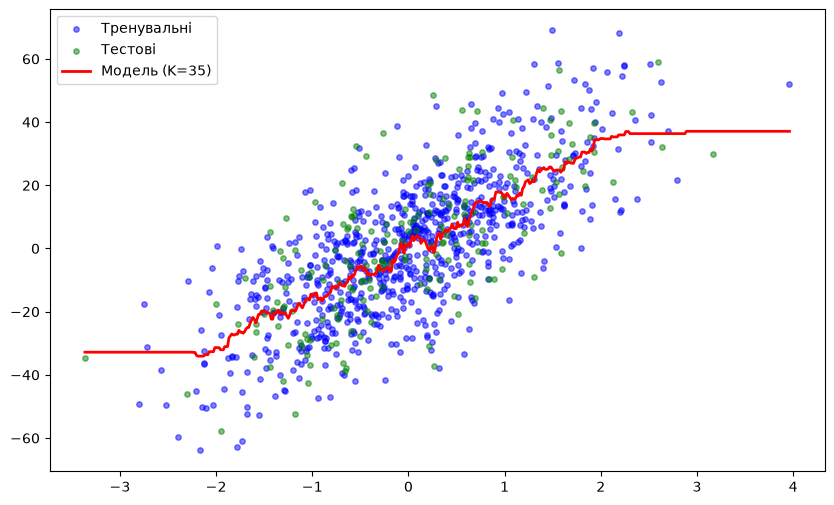

In [25]:
# Генерація даних
X_reg, y_reg = make_regression(n_samples=1000, n_features=1, noise=15, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Нормалізація
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

# Пошук найкращого K
best_k_reg, best_score_reg = 1, -float('inf')
for k in range(1, 50):
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_reg, y_train_reg)
    score = r2_score(y_test_reg, knn_reg.predict(X_test_reg))
    if score > best_score_reg:
        best_score_reg, best_k_reg = score, k

print(f"Регресія: Найкраще K = {best_k_reg}, R2 Score = {best_score_reg:.4f}")

# Навчання
knn_best_reg = KNeighborsRegressor(n_neighbors=best_k_reg)
knn_best_reg.fit(X_train_reg, y_train_reg)

# Візуалізація
X_plot = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)
y_plot = knn_best_reg.predict(scaler_reg.transform(X_plot))

plt.figure(figsize=(10, 6))
plt.scatter(X_train_reg, y_train_reg, color='blue', alpha=0.5, label='Тренувальні', s=15)
plt.scatter(X_test_reg, y_test_reg, color='green', alpha=0.5, label='Тестові', s=15)
plt.plot(scaler_reg.transform(X_plot), y_plot, color='red', linewidth=2, label=f'Модель (K={best_k_reg})')
plt.legend()
plt.show()